# Atividade - Previsao de Churn de Clientes

## Objetivo
Prever quais clientes de uma empresa de telecomunicacoes tem maior propensão a cancelar o servico (`Churn`), para tentar diminuir a desistencia dos clientes.

## Participantes

Nathan Gabriel da Silva - ``RA: 2077558``
Taina de Souza Alvez - ``RA: 2041631``
Júlia Soares de Azevedo Lombardi - ``RA: 2032874``

## 1. Importacao das bibliotecas





In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    roc_curve,
    auc,
)

sns.set_style("whitegrid")


## 2. Carregamento e inspecao inicial do dataset
Leitura do arquivo CSV e verificacao do tamanho, tipos e valores ausentes.

## ``Na hora que for testar, se tiver que baixar e jogar o dataset no projeto, cria uma pasta aqui no colab chamada "dataset", e joga-o dentro dela. O arquivo do dataset renomeia ele para "dataset.csv" pra nao dar erro no read_csv``


In [5]:
df = pd.read_csv("dataset/dataset.csv")

print("Dimensoes iniciais:", df.shape)
print("Informacoes gerais:")
print(df.info())
print("Valores ausentes por coluna:")
print(df.isnull().sum())

df.head()


Dimensoes iniciais: (7043, 21)
Informacoes gerais:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   obje

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## 3. Limpeza e preparo inicial dos dados



In [6]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
print("Valores ausentes em TotalCharges apos conversao:", df["TotalCharges"].isnull().sum())

df = df.dropna().copy()
df = df.drop(columns=["customerID"])
df["Churn"] = df["Churn"].map({"No": 0, "Yes": 1})


print("Distribuicao de Churn:")
print(df["Churn"].value_counts())


Valores ausentes em TotalCharges apos conversao: 11
Distribuicao de Churn:
Churn
0    5163
1    1869
Name: count, dtype: int64


## 4. Analise exploratoria dos dados (EDA)



In [7]:
print("Clientes que ficaram:", (df["Churn"] == 0).sum())
print("Clientes que cancelaram:", (df["Churn"] == 1).sum())
print("Proporcao de churn:")
print(df["Churn"].value_counts(normalize=True))


Clientes que ficaram: 5163
Clientes que cancelaram: 1869
Proporcao de churn:
Churn
0    0.734215
1    0.265785
Name: proportion, dtype: float64


In [8]:
print("Churn por tipo de contrato:")
print(pd.crosstab(df["Contract"], df["Churn"], normalize="index"))

print("Churn por metodo de pagamento:")
print(pd.crosstab(df["PaymentMethod"], df["Churn"], normalize="index"))

print("Churn por tipo de internet:")
print(pd.crosstab(df["InternetService"], df["Churn"], normalize="index"))


Churn por tipo de contrato:
Churn                  0         1
Contract                          
Month-to-month  0.572903  0.427097
One year        0.887228  0.112772
Two year        0.971513  0.028487
Churn por metodo de pagamento:
Churn                             0         1
PaymentMethod                                
Bank transfer (automatic)  0.832685  0.167315
Credit card (automatic)    0.847469  0.152531
Electronic check           0.547146  0.452854
Mailed check               0.807980  0.192020
Churn por tipo de internet:
Churn                   0         1
InternetService                    
DSL              0.810017  0.189983
Fiber optic      0.581072  0.418928
No               0.925658  0.074342


In [9]:
df["tenure_group"] = pd.cut(
    df["tenure"],
    bins=[0, 12, 24, 36, 72],
    labels=["0-12", "13-24", "25-36", "37+"],
    include_lowest=True,
)

print("Churn por faixa de tenure:")
print(pd.crosstab(df["tenure_group"], df["Churn"], normalize="index"))

print("Correlacao das variaveis numericas com Churn:")
print(df.corr(numeric_only=True)["Churn"].sort_values(ascending=False))


Churn por faixa de tenure:
Churn                0         1
tenure_group                    
0-12          0.523218  0.476782
13-24         0.712891  0.287109
25-36         0.783654  0.216346
37+           0.880706  0.119294
Correlacao das variaveis numericas com Churn:
Churn             1.000000
MonthlyCharges    0.192858
SeniorCitizen     0.150541
TotalCharges     -0.199484
tenure           -0.354049
Name: Churn, dtype: float64


## 5. Separacao entre variaveis preditoras e variavel alvo
`y` representa a coluna que queremos prever e o `X` contem as demais informacoes.


In [10]:
y = df["Churn"]
X = df.drop(columns=["Churn"])

num_cols = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
cat_cols = X.select_dtypes(include=["object", "category"]).columns.tolist()

print("Colunas numericas:", num_cols)
print("Colunas categoricas:", cat_cols)


Colunas numericas: ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']
Colunas categoricas: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'tenure_group']


## 6. Pre-processamento



In [11]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_cols),
        ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), cat_cols),
    ]
)


## 7. Divisao em treino, validacao e teste
A divisão foi feita em 60% treino, 20% validacao e 20% teste, com estratificacao da variavel alvo.


In [12]:
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.25, stratify=y_temp, random_state=42
)

print("Tamanho dos conjuntos:")
print("X_train:", X_train.shape)
print("X_val:", X_val.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_val:", y_val.shape)
print("y_test:", y_test.shape)


Tamanho dos conjuntos:
X_train: (4218, 20)
X_val: (1407, 20)
X_test: (1407, 20)
y_train: (4218,)
y_val: (1407,)
y_test: (1407,)


## 8. Treinamento dos tres classificadores
Treinando os 3 modelos recomendados do PDF


In [13]:
log_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000, random_state=42)),
])

rf_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(random_state=42)),
])

gb_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", GradientBoostingClassifier(random_state=42)),
])

models = {
    "Logistic Regression": log_model,
    "Random Forest": rf_model,
    "Gradient Boosting": gb_model,
}

for model in models.values():
    model.fit(X_train, y_train)


## 9. Avaliacao inicial dos modelos no conjunto de validacao



In [14]:
preds = {}
probs = {}
resultados = []

for nome, model in models.items():
    y_pred = model.predict(X_val)
    y_prob = model.predict_proba(X_val)[:, 1]

    preds[nome] = y_pred
    probs[nome] = y_prob

    resultados.append({
        "Modelo": nome,
        "Accuracy": accuracy_score(y_val, y_pred),
        "Precision": precision_score(y_val, y_pred),
        "Recall": recall_score(y_val, y_pred),
        "F1-score": f1_score(y_val, y_pred),
        "AUC-ROC": roc_auc_score(y_val, y_prob),
    })

resultados_df = pd.DataFrame(resultados).sort_values(by="AUC-ROC", ascending=False)
resultados_df.round(4)


,Modelo,Accuracy,Precision,Recall,F1-score,AUC-ROC
2,Gradient Boosting,0.7946,0.6641,0.4599,0.5434,0.8369
0,Logistic Regression,0.7925,0.6507,0.4733,0.5480,0.8339
1,Random Forest,0.7854,0.6395,0.4412,0.5222,0.8168


## 10. Validacao cruzada com Stratified K-Fold (k = 5)



In [15]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_resultados = []
for nome, model in models.items():
    acc_scores = cross_val_score(model, X, y, cv=skf, scoring="accuracy")
    auc_scores = cross_val_score(model, X, y, cv=skf, scoring="roc_auc")

    cv_resultados.append({
        "Modelo": nome,
        "CV Accuracy Media": acc_scores.mean(),
        "CV AUC Media": auc_scores.mean(),
    })

cv_resultados_df = pd.DataFrame(cv_resultados).sort_values(by="CV AUC Media", ascending=False)
cv_resultados_df.round(4)


,Modelo,CV Accuracy Media,CV AUC Media
0,Logistic Regression,0.8055,0.8467
2,Gradient Boosting,0.8032,0.8458
1,Random Forest,0.7927,0.8233


## 11. Matrizes de confusao



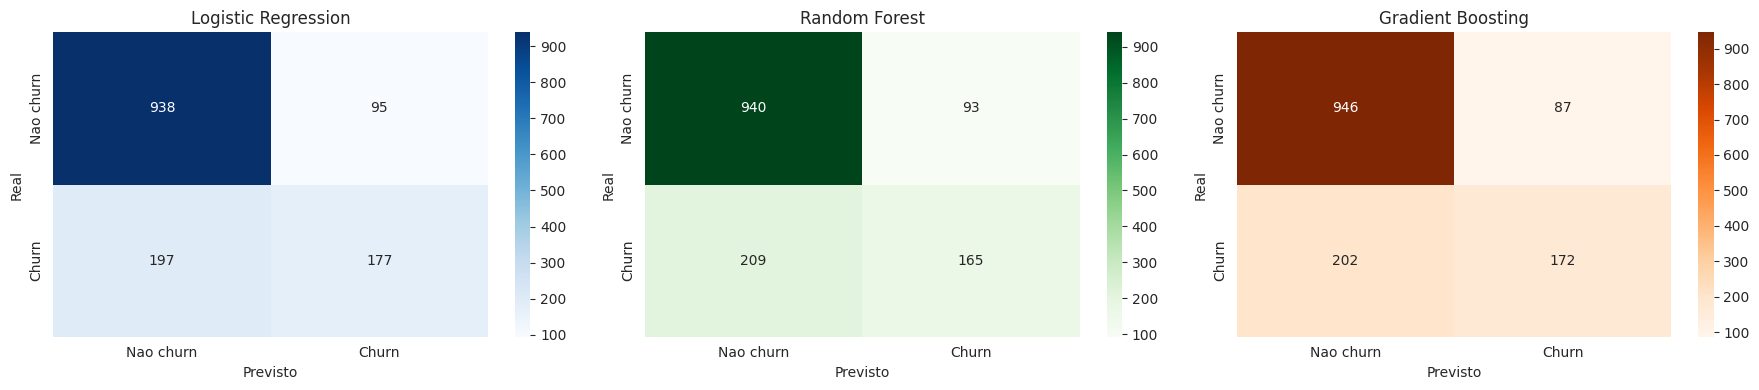

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
cores = ["Blues", "Greens", "Oranges"]

for ax, (nome, y_pred), cmap in zip(axes, preds.items(), cores):
    cm = confusion_matrix(y_val, y_pred)
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap=cmap,
        xticklabels=["Nao churn", "Churn"],
        yticklabels=["Nao churn", "Churn"],
        ax=ax,
    )
    ax.set_title(nome)
    ax.set_xlabel("Previsto")
    ax.set_ylabel("Real")

plt.tight_layout()
plt.show()


## 12. Curvas ROC/AUC sobrepostas



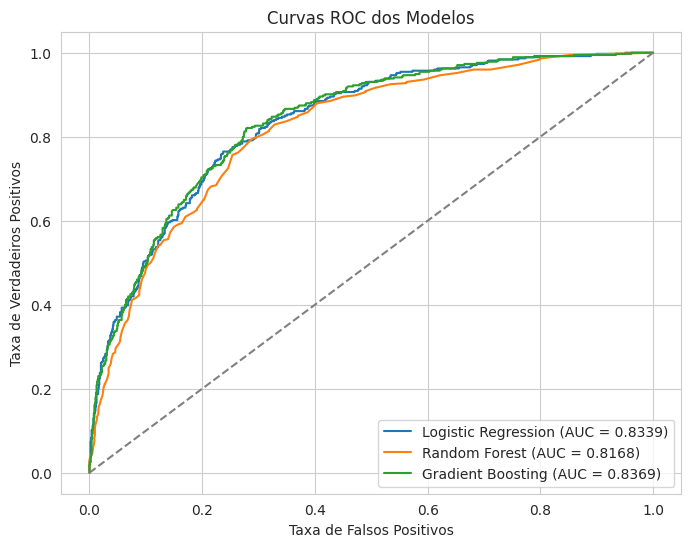

In [17]:
plt.figure(figsize=(8, 6))

for nome in models.keys():
    fpr, tpr, _ = roc_curve(y_val, probs[nome])
    auc_score = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{nome} (AUC = {auc_score:.4f})")

plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
plt.xlabel("Taxa de Falsos Positivos")
plt.ylabel("Taxa de Verdadeiros Positivos")
plt.title("Curvas ROC dos Modelos")
plt.legend()
plt.show()


## 13. Feature Importance do Random Forest



In [18]:
rf_classifier = rf_model.named_steps["classifier"]
rf_preprocessor = rf_model.named_steps["preprocessor"]

feature_names = rf_preprocessor.get_feature_names_out()
importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": rf_classifier.feature_importances_,
}).sort_values(by="Importance", ascending=False)

importance_df.head(10)


,Feature,Importance
3,num__TotalCharges,0.183308
2,num__MonthlyCharges,0.155627
1,num__tenure,0.146948
10,cat__InternetService_Fiber optic,0.046830
28,cat__PaymentMethod_Electronic check,0.036925
4,cat__gender_Male,0.028097
32,cat__tenure_group_37+,0.027356
26,cat__PaperlessBilling_Yes,0.026938
13,cat__OnlineSecurity_Yes,0.025651
19,cat__TechSupport_Yes,0.025229


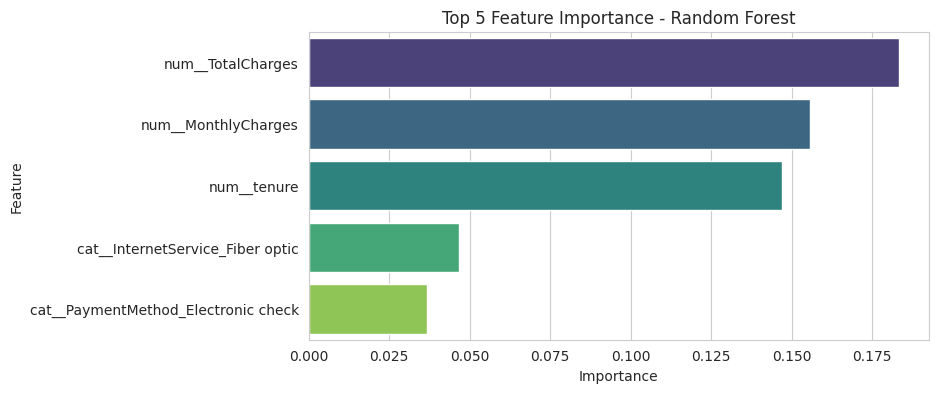

In [19]:
top5 = importance_df.head(5)

plt.figure(figsize=(8, 4))
sns.barplot(data=top5, x="Importance", y="Feature", hue="Feature", palette="viridis", legend=False)
plt.title("Top 5 Feature Importance - Random Forest")
plt.show()


## 14. Interpretacao dos coeficientes da Logistic Regression



In [20]:
log_classifier = log_model.named_steps["classifier"]
log_preprocessor = log_model.named_steps["preprocessor"]

coef_df = pd.DataFrame({
    "Feature": log_preprocessor.get_feature_names_out(),
    "Coeficiente": log_classifier.coef_[0],
}).sort_values(by="Coeficiente", ascending=False)

print("Maiores coeficientes positivos:")
display(coef_df.head(5))

print("Maiores coeficientes negativos:")
display(coef_df.tail(5))


Maiores coeficientes positivos:


,Feature,Coeficiente
10,cat__InternetService_Fiber optic,1.034946
32,cat__tenure_group_37+,0.663313
9,cat__MultipleLines_Yes,0.428672
23,cat__StreamingMovies_Yes,0.352164
21,cat__StreamingTV_Yes,0.319694


Maiores coeficientes negativos:


,Feature,Coeficiente
13,cat__OnlineSecurity_Yes,-0.400516
7,cat__PhoneService_Yes,-0.497361
24,cat__Contract_One year,-0.882059
1,num__tenure,-1.342873
25,cat__Contract_Two year,-1.384365


## 15. Escolha do melhor modelo e avaliacao final no conjunto de teste
Nesse caso o `Gradient Boosting` foi o melhor modelo dos 3.


In [21]:
best_model_name = resultados_df.iloc[0]["Modelo"]
best_model = models[best_model_name]

y_test_pred = best_model.predict(X_test)
y_test_prob = best_model.predict_proba(X_test)[:, 1]

resultado_teste = pd.DataFrame([
    {
        "Modelo escolhido": best_model_name,
        "Accuracy": accuracy_score(y_test, y_test_pred),
        "Precision": precision_score(y_test, y_test_pred),
        "Recall": recall_score(y_test, y_test_pred),
        "F1-score": f1_score(y_test, y_test_pred),
        "AUC-ROC": roc_auc_score(y_test, y_test_prob),
    }
])

resultado_teste.round(4)


,Modelo escolhido,Accuracy,Precision,Recall,F1-score,AUC-ROC
0,Gradient Boosting,0.7939,0.6373,0.5214,0.5735,0.8398


## 16. Conclusao

O modelo **Gradient Boosting** apresentou o melhor desempenho geral, obtendo os melhores valores de `Accuracy` e `AUC-ROC` na comparacao principal. Isso indica melhor capacidade de separar clientes que desistiram dos clientes que nao desistiram.

A **Logistic Regression** tambem teve destaque, principalmente por apresentar melhor `Recall` e `F1-score`, o que e relevante em churn, ja que identificar clientes em risco de cancelamento e uma prioridade de negocio.

Pela analise exploratoria, variaveis como `tenure`, tipo de `Contract`, `MonthlyCharges` e servicos associados ao plano mostraram relacao importante com o churn. No `Random Forest`, as features mais importantes reforcam essa interpretacao, enquanto os coeficientes da `Logistic Regression` ajudam a entender a direcao do efeito de cada variavel.
